# SHREC — Shared Recurrence Embedding for Causal Analysis
### Applied to the California Sardine / Anchovy / SST system

**What this notebook does, in order:**

| Section | Description |
|---------|-------------|
| 1 | Data loading from `sardine_anchovy_sst.csv` and z-score normalisation |
| 2 | Shared helper functions (recurrence matrix, SHREC pipeline) |
| 3 | **4-variable SHREC** — joint manifold for Anchovy, Sardine, SST-SIO, SST-NP |
| 4 | **Pairwise SHREC** — all six 2-variable pairs |
| 5 | **Spectral decomposition** of ψ₁ — FFT, Welch PSD, SSA, STL, spectrogram |

The CSV `shrec_1var_latent_coordinates.csv` (consumed by the SINDy notebook)  
is written at the end of Section 3 **only if it does not already exist**.

## Section 1 — Imports & Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial.distance import cdist
from scipy.linalg import eigh, svd
from scipy.signal import welch, find_peaks, spectrogram
from scipy.fft import rfft, rfftfreq, irfft
from statsmodels.tsa.seasonal import STL

print("All imports OK.")


All imports OK.


In [2]:
# ── Load from CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv('sardine_anchovy_sst.csv')
df['year'] = pd.to_datetime(df['year'].astype(str), format='%Y')
df = df.sort_values('year').set_index('year').interpolate(method='linear')

years   = df.index.year.values
anchovy = df['anchovy'].values
sardine = df['sardine'].values
sio_sst = df['sio_sst'].values
np_sst  = df['np_sst'].values

print(f"Loaded {len(years)} annual observations ({years[0]}–{years[-1]})")

# ── Z-score normalisation ─────────────────────────────────────────────────────
def zscore(ts):
    return (ts - np.mean(ts)) / (np.std(ts) + 1e-12)

anchovy_n = zscore(anchovy)
sardine_n = zscore(sardine)
sio_sst_n = zscore(sio_sst)
np_sst_n  = zscore(np_sst)

print("Variables z-scored: anchovy_n, sardine_n, sio_sst_n, np_sst_n")


Loaded 78 annual observations (1929–2006)
Variables z-scored: anchovy_n, sardine_n, sio_sst_n, np_sst_n


## Section 2 — Shared Helper Functions

All SHREC logic lives here and is reused unchanged across Sections 3 and 4.

- `create_recurrence_matrix` — builds a localised k-NN affinity matrix from  
  a delay-embedding of one time series.
- `shrec_reconstruct` — sums affinity matrices across all input series,  
  normalises to a graph Laplacian, and returns the leading eigenvectors (ψ modes).


In [3]:
# ── Recurrence / affinity matrix ──────────────────────────────────────────────
def create_recurrence_matrix(ts, E=3, tau=1, k=10):
    """k-NN Gaussian affinity matrix from a delay embedding of ts."""
    n       = len(ts)
    n_embed = n - (E - 1) * tau
    M = np.array([[ts[i + (E-1)*tau - j*tau] for j in range(E)]
                  for i in range(n_embed)])
    dists = cdist(M, M, metric='euclidean')
    A = np.zeros_like(dists)
    for i in range(n_embed):
        nn_idx  = np.argsort(dists[i])[1:k+1]
        sigma   = np.mean(dists[i, nn_idx]) + 1e-12
        A[i, nn_idx] = np.exp(-dists[i, nn_idx]**2 / (2 * sigma**2))
    return (A + A.T) / 2


# ── SHREC pipeline ────────────────────────────────────────────────────────────
def shrec_reconstruct(ts_list, E=3, tau=1, k=10, n_components=2):
    """Shared Recurrence Embedding:
    sum affinity matrices → graph Laplacian → leading eigenvectors."""
    A_consensus = np.sum(
        [create_recurrence_matrix(ts, E=E, tau=tau, k=k) for ts in ts_list],
        axis=0
    )
    deg         = np.sum(A_consensus, axis=1)
    deg[deg == 0] = 1e-12
    D_inv_sqrt  = np.diag(1.0 / np.sqrt(deg))
    L           = np.eye(len(A_consensus)) - D_inv_sqrt @ A_consensus @ D_inv_sqrt
    eigvals, eigvecs = eigh(L)
    idx = np.argsort(eigvals)
    return eigvecs[:, idx][:, 1:1+n_components]


# ── Global SHREC parameters ───────────────────────────────────────────────────
E_PARAM   = 3    # embedding dimension
K_PARAM   = 10   # number of nearest neighbours
TRIM      = E_PARAM - 1   # rows lost at the front of each embedding
time_axis = years[TRIM:]  # shared time axis for all SHREC outputs

print(f"Helper functions defined.  time_axis: {time_axis[0]}–{time_axis[-1]}  ({len(time_axis)} pts)")


Helper functions defined.  time_axis: 1931–2006  (76 pts)


## Section 3 — 4-Variable SHREC (full joint manifold)

We run SHREC on all four variables simultaneously to extract the **shared latent
trajectory** ψ₁ that captures collective ecosystem dynamics.

The output CSV `shrec_1var_latent_coordinates.csv` is written here (skipped if  
the file already exists) so the SINDy notebook can consume it without re-running.

In [4]:
# ── Run 4-variable SHREC ──────────────────────────────────────────────────────
latent_modes = shrec_reconstruct(
    [anchovy_n, sardine_n, sio_sst_n, np_sst_n],
    E=E_PARAM, tau=1, k=K_PARAM, n_components=2
)

psi_1 = zscore(latent_modes[:, 0])
psi_2 = zscore(latent_modes[:, 1])

print(f"4-var SHREC complete.  ψ₁ shape: {psi_1.shape}")


4-var SHREC complete.  ψ₁ shape: (76,)


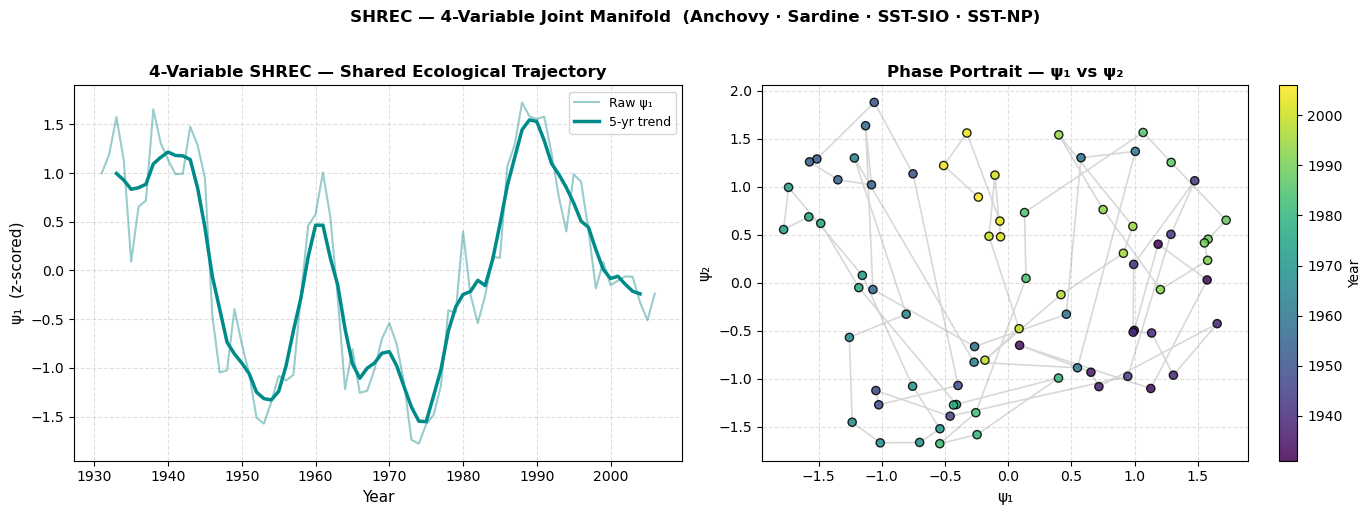

In [5]:
# ── Plot: shared trajectory + phase portrait ──────────────────────────────────
WINDOW = 5
half_w = WINDOW // 2
smoothed = np.convolve(psi_1, np.ones(WINDOW) / WINDOW, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — trajectory over time
ax = axes[0]
ax.plot(time_axis, psi_1, color='teal', alpha=0.4, label='Raw ψ₁')
ax.plot(time_axis[half_w:-half_w], smoothed[half_w:-half_w],
        color='darkcyan', lw=2.5, label=f'{WINDOW}-yr trend')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('ψ₁  (z-scored)', fontsize=11)
ax.set_title('4-Variable SHREC — Shared Ecological Trajectory', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(ls='--', alpha=0.4)

# Right — phase portrait ψ₁ vs ψ₂
ax = axes[1]
sc = ax.scatter(psi_1, psi_2, c=time_axis, cmap='viridis', s=35,
                edgecolor='k', alpha=0.85, zorder=3)
ax.plot(psi_1, psi_2, color='gray', alpha=0.3, lw=1.2, zorder=2)
ax.set_xlabel('ψ₁', fontsize=11); ax.set_ylabel('ψ₂', fontsize=11)
ax.set_title('Phase Portrait — ψ₁ vs ψ₂', fontsize=12, fontweight='bold')
ax.grid(ls='--', alpha=0.4)
fig.colorbar(sc, ax=ax, label='Year')

plt.suptitle('SHREC — 4-Variable Joint Manifold  (Anchovy · Sardine · SST-SIO · SST-NP)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# ── Save shrec_1var_latent_coordinates.csv (for SINDy notebook) ───────────────
OUTPUT_CSV = 'shrec_1var_latent_coordinates.csv'

if os.path.exists(OUTPUT_CSV):
    print(f"File already exists — skipping write: {OUTPUT_CSV}")
else:
    shrec_df = pd.DataFrame({
        'Year'              : time_axis.astype(int),
        'Psi_1_Standardized': psi_1,
        'Psi_2_Standardized': psi_2,
        'Raw_Component_1'   : latent_modes[:, 0],
        'Raw_Component_2'   : latent_modes[:, 1],
    })
    shrec_df.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved {len(shrec_df)} rows to '{OUTPUT_CSV}'")
    print("Columns:", list(shrec_df.columns))


File already exists — skipping write: shrec_1var_latent_coordinates.csv


## Section 4 — Pairwise SHREC (all six 2-variable pairs)

Each panel shows ψ₁ for one pair of variables.  
This lets us compare which pair's latent trajectory best tracks  
the collective ecosystem signal from Section 3.

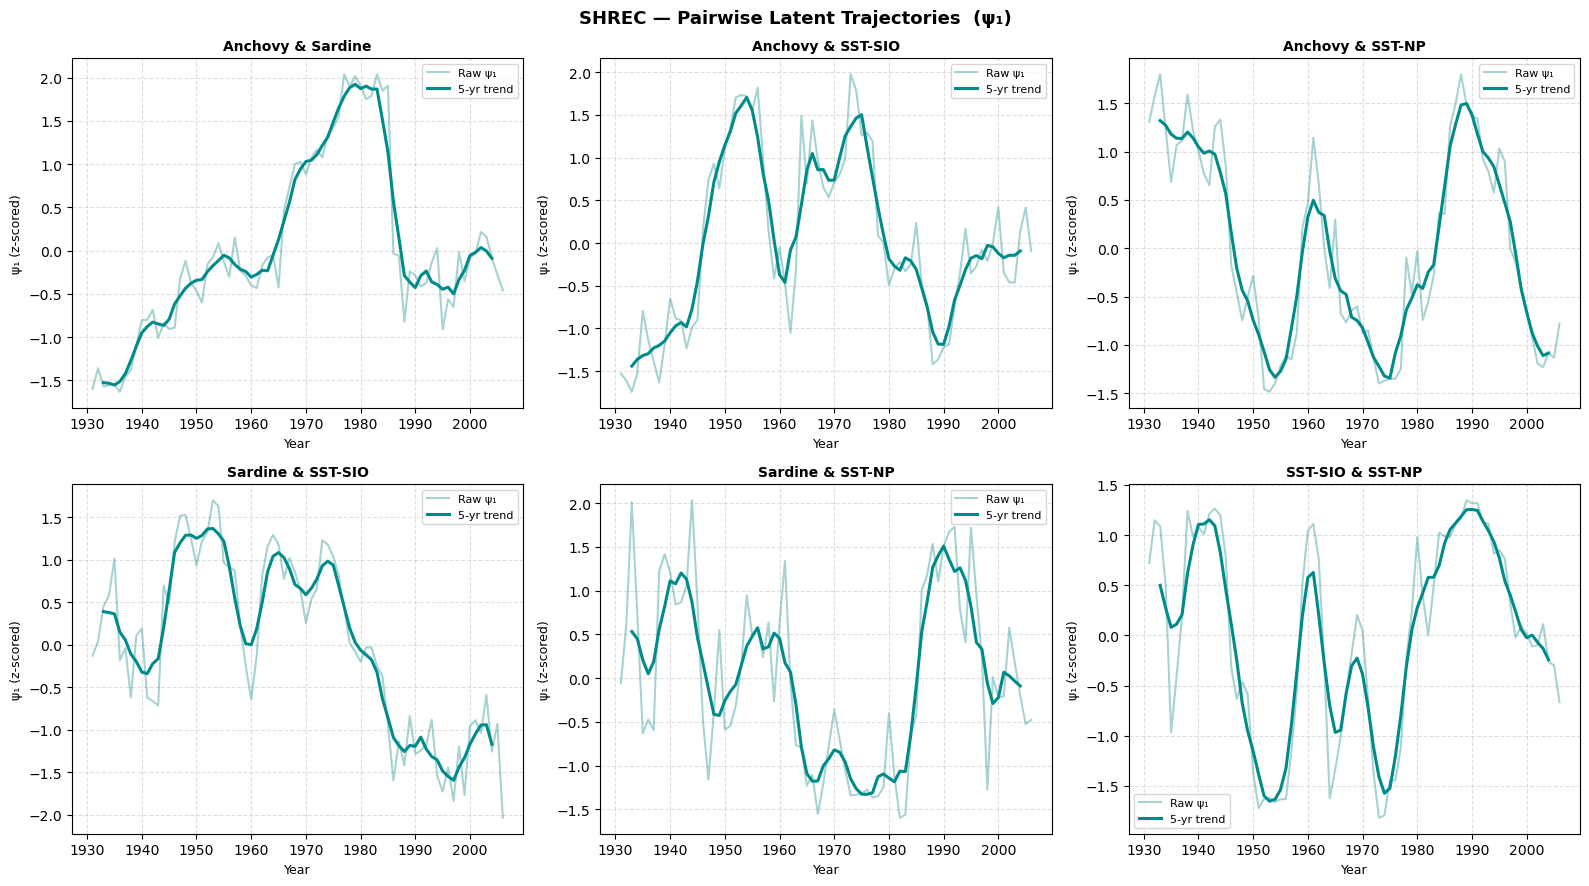

Pairwise SHREC complete for all 6 pairs.


In [7]:
# ── Define all 6 pairs ────────────────────────────────────────────────────────
PAIRS = [
    (anchovy_n, sardine_n, 'Anchovy & Sardine'),
    (anchovy_n, sio_sst_n, 'Anchovy & SST-SIO'),
    (anchovy_n, np_sst_n,  'Anchovy & SST-NP'),
    (sardine_n, sio_sst_n, 'Sardine & SST-SIO'),
    (sardine_n, np_sst_n,  'Sardine & SST-NP'),
    (sio_sst_n, np_sst_n,  'SST-SIO & SST-NP'),
]

# ── Run and plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
all_psi1_pairs = {}

for ax, (ts_a, ts_b, label) in zip(axes.flat, PAIRS):
    modes  = shrec_reconstruct([ts_a, ts_b], E=E_PARAM, tau=1, k=K_PARAM, n_components=2)
    p1     = zscore(modes[:, 0])
    all_psi1_pairs[label] = p1

    smooth = np.convolve(p1, np.ones(WINDOW) / WINDOW, mode='same')
    ax.plot(time_axis, p1, color='teal', alpha=0.35, label='Raw ψ₁')
    ax.plot(time_axis[half_w:-half_w], smooth[half_w:-half_w],
            color='darkcyan', lw=2.2, label=f'{WINDOW}-yr trend')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9); ax.set_ylabel('ψ₁ (z-scored)', fontsize=9)
    ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

fig.suptitle('SHREC — Pairwise Latent Trajectories  (ψ₁)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Pairwise SHREC complete for all 6 pairs.")


In [8]:
# ── Save pairwise ψ₁ to CSV ──────────────────────────────────────────────────
PAIR_CSV = 'shrec_pairwise_latent_coordinates.csv'
pair_df  = pd.DataFrame({'Year': time_axis.astype(int)} |
           {label.replace(' ', '_').replace('&', 'and'): psi
            for label, psi in all_psi1_pairs.items()})
pair_df.to_csv(PAIR_CSV, index=False)
print(f"Saved pairwise ψ₁ to '{PAIR_CSV}'")
print("Columns:", list(pair_df.columns))


Saved pairwise ψ₁ to 'shrec_pairwise_latent_coordinates.csv'
Columns: ['Year', 'Anchovy_and_Sardine', 'Anchovy_and_SST-SIO', 'Anchovy_and_SST-NP', 'Sardine_and_SST-SIO', 'Sardine_and_SST-NP', 'SST-SIO_and_SST-NP']


## Section 5 — Spectral Decomposition of ψ₁

We decompose the 4-variable ψ₁ using four complementary methods:

| Method | What it reveals |
|--------|----------------|
| **FFT amplitude spectrum** | dominant periodicities in frequency domain |
| **Welch PSD** | smoothed power spectrum with peak detection |
| **SSA** (Singular Spectrum Analysis) | trend / oscillatory / noise separation via SVD |
| **STL** (Seasonal-Trend-Loess) | decadal (PDO-like) and interannual (ENSO-like) components |
| **STFT Spectrogram** | how dominant periods shift over time |

In [9]:
# ── Shared signal setup ───────────────────────────────────────────────────────
sig_psi1  = latent_modes[:, 0]   # raw (not z-scored) ψ₁ for decomposition
sig_psi2  = latent_modes[:, 1]
n         = len(sig_psi1)
fs        = 1.0                  # 1 observation per year
modes_dec = {'ψ₁ (raw)': sig_psi1, 'ψ₂ (raw)': sig_psi2}
print(f"Signal length: {n} years  |  sampling: {fs} yr⁻¹")


Signal length: 76 years  |  sampling: 1.0 yr⁻¹


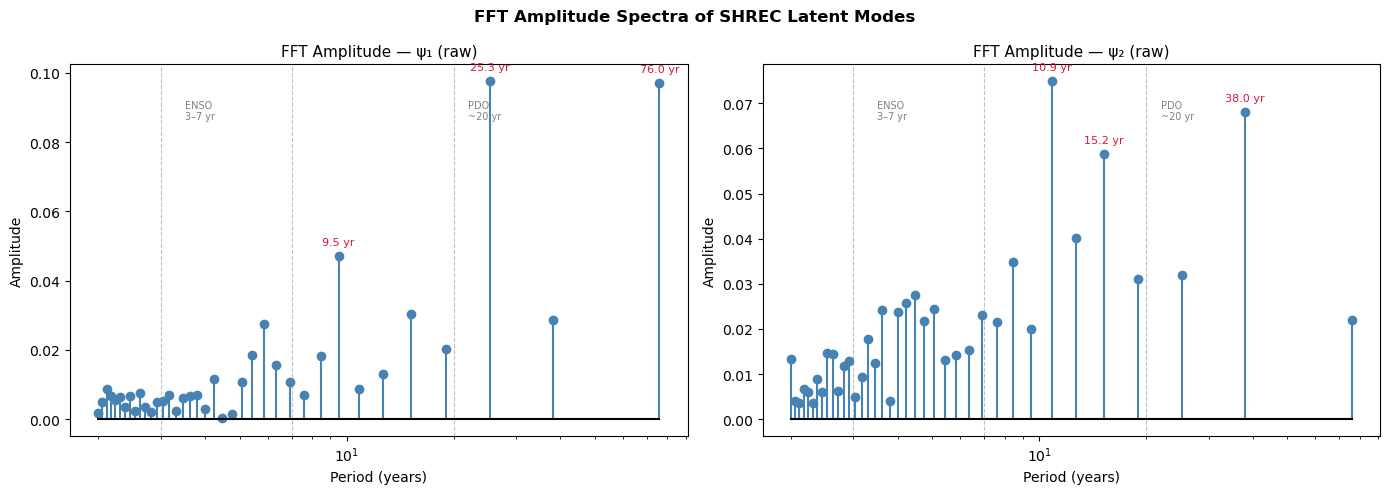

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 5a — FFT AMPLITUDE SPECTRUM
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fft_results = {}

for ax, (label, sig) in zip(axes, modes_dec.items()):
    sig_zm = sig - sig.mean()
    coeffs = rfft(sig_zm)
    freqs  = rfftfreq(n, d=1.0 / fs)
    amp    = np.abs(coeffs) * 2 / n
    amp[0] /= 2
    with np.errstate(divide='ignore'):
        periods = np.where(freqs > 0, 1.0 / freqs, np.inf)
    fft_results[label] = dict(coeffs=coeffs, freqs=freqs, amp=amp, periods=periods, sig_zm=sig_zm)

    valid = freqs > 0
    ax.stem(periods[valid], amp[valid], linefmt='steelblue', markerfmt='o', basefmt='k-')
    ax.set_xscale('log')
    ax.set_xlabel('Period (years)', fontsize=10); ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f'FFT Amplitude — {label}', fontsize=11)
    for idx in np.argsort(amp[valid])[-3:][::-1]:
        ax.annotate(f'{periods[valid][idx]:.1f} yr',
                    xy=(periods[valid][idx], amp[valid][idx]),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=8, color='crimson')
    for p in [3, 7, 20]:
        ax.axvline(p, color='gray', lw=0.8, ls='--', alpha=0.5)
    ylim = ax.get_ylim()
    ax.text(3.5, ylim[1]*0.9, 'ENSO\n3–7 yr', fontsize=7, color='gray', va='top')
    ax.text(22,  ylim[1]*0.9, 'PDO\n~20 yr',  fontsize=7, color='gray', va='top')

fig.suptitle('FFT Amplitude Spectra of SHREC Latent Modes', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


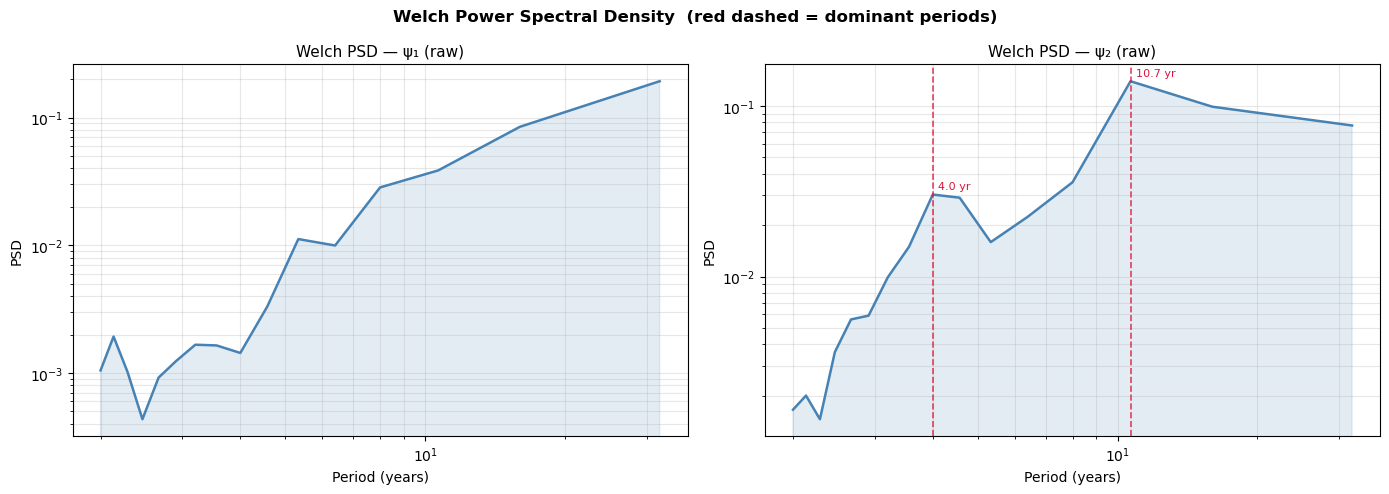

Dominant periods (Welch peaks):
  ψ₁ (raw): []
  ψ₂ (raw): ['4.0 yr', '10.7 yr']


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 5b — WELCH POWER SPECTRAL DENSITY
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
welch_peaks = {}

for ax, (label, sig) in zip(axes, modes_dec.items()):
    sig_zm = sig - sig.mean()
    f_w, pxx = welch(sig_zm, fs=fs, nperseg=min(32, n // 2),
                     noverlap=None, window='hann', scaling='density')
    valid = f_w > 0
    f_v, p_v = f_w[valid], pxx[valid]
    per_v    = 1.0 / f_v

    peak_idx, props = find_peaks(p_v, prominence=0.05 * p_v.max(), distance=2)
    top_pk = peak_idx[np.argsort(props['prominences'])[::-1][:4]]

    ax.semilogy(per_v, p_v, color='steelblue', lw=1.8)
    ax.fill_between(per_v, p_v, alpha=0.15, color='steelblue')
    dom_periods = []
    for pk in top_pk:
        ax.axvline(per_v[pk], color='crimson', lw=1.2, ls='--', alpha=0.8)
        ax.annotate(f'{per_v[pk]:.1f} yr', xy=(per_v[pk], p_v[pk]),
                    xytext=(4, 4), textcoords='offset points', fontsize=8, color='crimson')
        dom_periods.append(per_v[pk])
    welch_peaks[label] = sorted(dom_periods)
    ax.set_xscale('log')
    ax.set_xlabel('Period (years)', fontsize=10); ax.set_ylabel('PSD', fontsize=10)
    ax.set_title(f'Welch PSD — {label}', fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Welch Power Spectral Density  (red dashed = dominant periods)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("Dominant periods (Welch peaks):")
for lbl, pers in welch_peaks.items():
    print(f"  {lbl}: {[f'{p:.1f} yr' for p in pers]}")


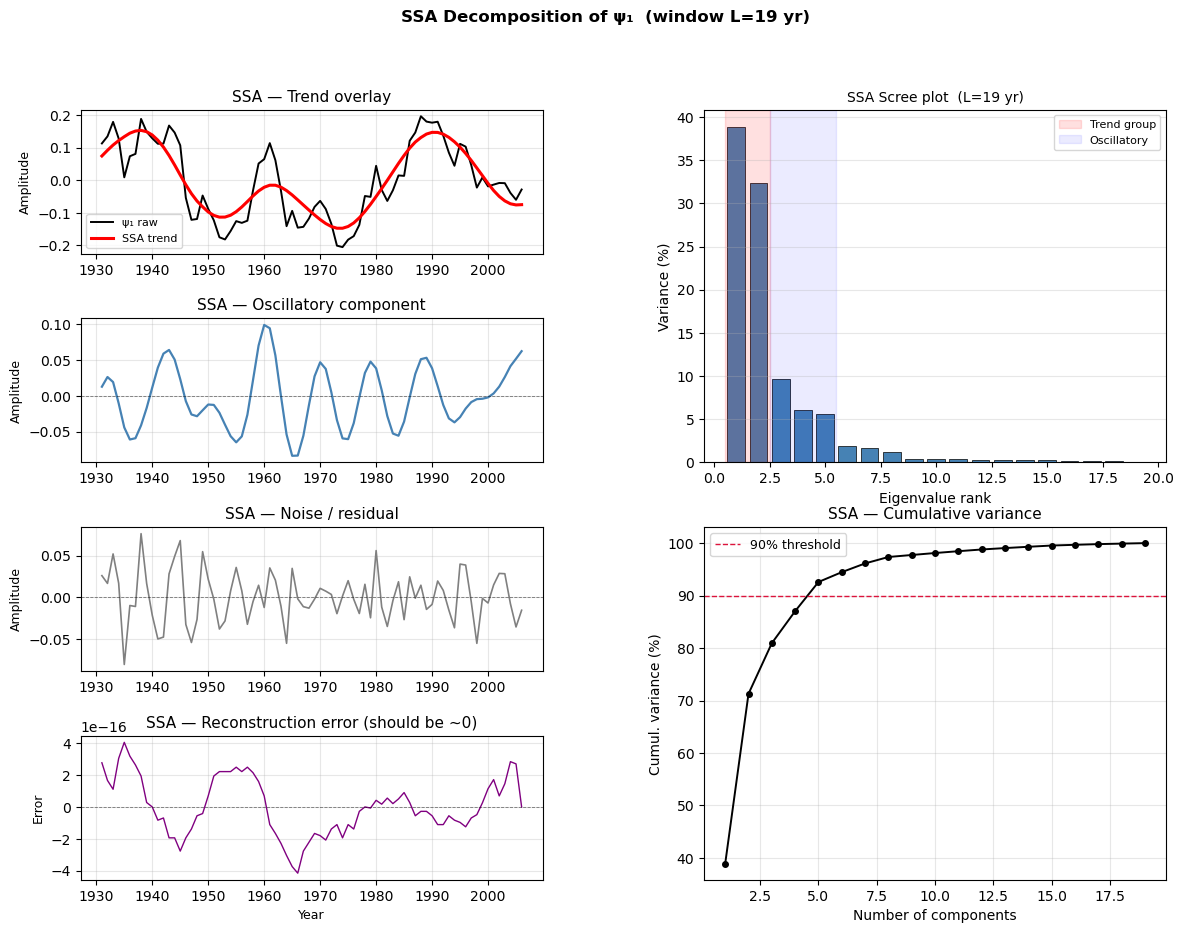

SSA summary (L=19, n=76):
  Trend (ranks 1-2): 71.3% cumul. variance
  90% threshold at rank: 5


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 5c — SSA  (Singular Spectrum Analysis)
# ══════════════════════════════════════════════════════════════════════════════
def ssa_diagonal_average(X_group):
    """Anti-diagonal average of an L×K matrix → time series of length L+K-1."""
    L, K   = X_group.shape
    result = np.zeros(L + K - 1)
    counts = np.zeros(L + K - 1)
    for i in range(L):
        for j in range(K):
            result[i + j] += X_group[i, j]
            counts[i + j] += 1
    return result / counts


def run_ssa(sig, L=None, n_trend=2):
    """Full SSA decomposition → (trend, oscillatory, noise, singular_values, cumvar)."""
    sig_zm = sig - sig.mean()
    N = len(sig_zm)
    L = L or max(4, N // 4)
    K = N - L + 1
    X = np.array([sig_zm[i:i+L] for i in range(K)]).T
    U, s, Vt   = svd(X, full_matrices=False)
    X_comps    = [s[i] * np.outer(U[:, i], Vt[i, :]) for i in range(len(s))]
    var_cumul  = np.cumsum(s**2) / np.sum(s**2)
    n_keep     = max(int(np.searchsorted(var_cumul, 0.90)) + 1, n_trend + 1)
    trend_ts   = ssa_diagonal_average(sum(X_comps[:n_trend]))
    osc_ts     = ssa_diagonal_average(sum(X_comps[n_trend:n_keep]))
    noise_ts   = ssa_diagonal_average(sum(X_comps[n_keep:]))
    return trend_ts + sig.mean(), osc_ts, noise_ts, s, var_cumul


L_ssa = max(4, n // 4)
ssa_trend, ssa_osc, ssa_noise, ssa_sv, ssa_var = run_ssa(sig_psi1, L=L_ssa, n_trend=2)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(time_axis, sig_psi1, 'k-', lw=1.4, label='ψ₁ raw')
ax0.plot(time_axis, ssa_trend[:n], 'r-', lw=2.2, label='SSA trend')
ax0.set_title('SSA — Trend overlay', fontsize=11)
ax0.set_ylabel('Amplitude', fontsize=9); ax0.legend(fontsize=8); ax0.grid(alpha=0.3)

ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(time_axis, ssa_osc[:n], color='steelblue', lw=1.6)
ax1.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax1.set_title('SSA — Oscillatory component', fontsize=11)
ax1.set_ylabel('Amplitude', fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[2, 0])
ax2.plot(time_axis, ssa_noise[:n], color='gray', lw=1.2)
ax2.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax2.set_title('SSA — Noise / residual', fontsize=11)
ax2.set_ylabel('Amplitude', fontsize=9); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[3, 0])
check = ssa_trend[:n] + ssa_osc[:n] + ssa_noise[:n]
ax3.plot(time_axis, sig_psi1 - check, color='purple', lw=1.0)
ax3.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax3.set_title('SSA — Reconstruction error (should be ~0)', fontsize=11)
ax3.set_ylabel('Error', fontsize=9); ax3.set_xlabel('Year', fontsize=9); ax3.grid(alpha=0.3)

n_show = min(20, len(ssa_sv))
ax4 = fig.add_subplot(gs[0:2, 1])
ax4.bar(range(1, n_show+1), (ssa_sv[:n_show]**2) / np.sum(ssa_sv**2) * 100,
        color='steelblue', edgecolor='k', lw=0.5)
ax4.axvspan(0.5, 2.5, color='red',  alpha=0.12, label='Trend group')
ax4.axvspan(2.5, min(int(np.searchsorted(ssa_var, 0.90))+1.5, n_show+0.5),
            color='blue', alpha=0.08, label='Oscillatory')
ax4.set_xlabel('Eigenvalue rank', fontsize=10); ax4.set_ylabel('Variance (%)', fontsize=10)
ax4.set_title(f'SSA Scree plot  (L={L_ssa} yr)', fontsize=10)
ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(gs[2:4, 1])
ax5.plot(range(1, n_show+1), ssa_var[:n_show]*100, 'ko-', ms=4, lw=1.4)
ax5.axhline(90, color='crimson', ls='--', lw=1, label='90% threshold')
ax5.set_xlabel('Number of components', fontsize=10); ax5.set_ylabel('Cumul. variance (%)', fontsize=10)
ax5.set_title('SSA — Cumulative variance', fontsize=11)
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

fig.suptitle(f'SSA Decomposition of ψ₁  (window L={L_ssa} yr)', fontsize=12, fontweight='bold')
plt.show()

print(f"SSA summary (L={L_ssa}, n={n}):")
print(f"  Trend (ranks 1-2): {ssa_var[1]*100:.1f}% cumul. variance")
print(f"  90% threshold at rank: {int(np.searchsorted(ssa_var, 0.90)) + 1}")


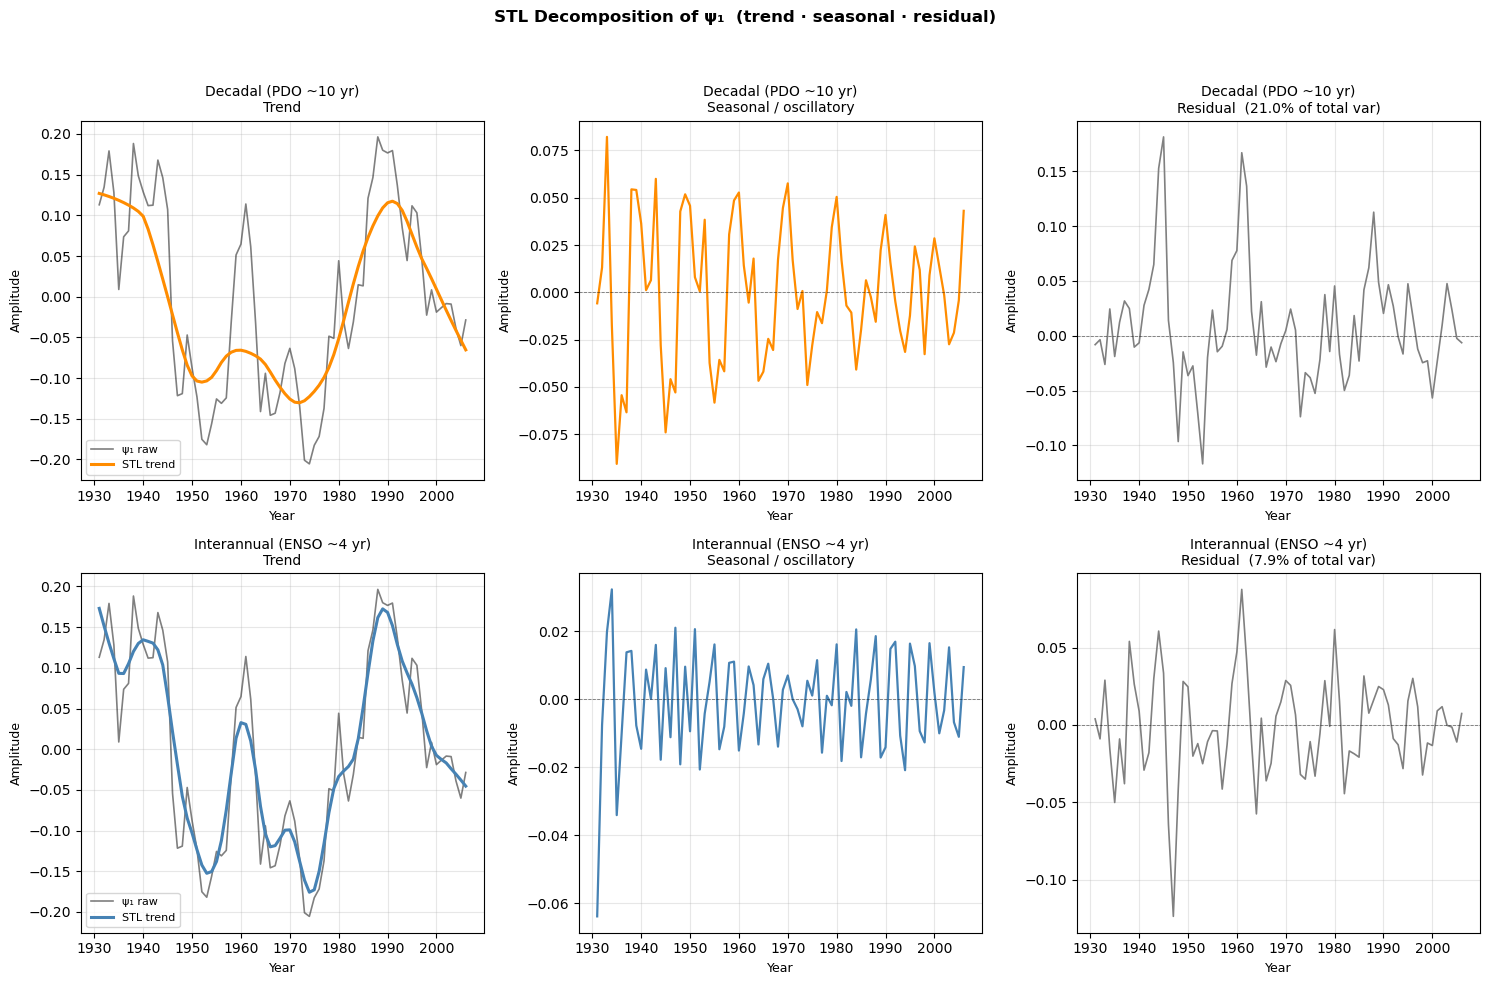

STL summary:
  Decadal (PDO ~10 yr)                 trend=56.8%  seasonal=9.9%  residual=21.0%
  Interannual (ENSO ~4 yr)             trend=80.2%  seasonal=1.7%  residual=7.9%


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 5d — STL  (Seasonal-Trend Decomposition via Loess)
# ══════════════════════════════════════════════════════════════════════════════
stl_configs = [
    dict(period=10, seasonal=11, label='Decadal (PDO ~10 yr)',       color='darkorange'),
    dict(period=4,  seasonal=7,  label='Interannual (ENSO ~4 yr)',   color='steelblue'),
]

fig, axes = plt.subplots(len(stl_configs), 3, figsize=(15, 5 * len(stl_configs)))
fig.suptitle("STL Decomposition of ψ₁  (trend · seasonal · residual)",
             fontsize=12, fontweight='bold')

stl_results = {}
for row, cfg in enumerate(stl_configs):
    res = STL(sig_psi1, period=cfg['period'], seasonal=cfg['seasonal'], robust=True).fit()
    stl_results[cfg['label']] = res
    col = cfg['color']

    axes[row, 0].plot(time_axis, sig_psi1, 'k-', lw=1.2, alpha=0.5, label='ψ₁ raw')
    axes[row, 0].plot(time_axis, res.trend, color=col, lw=2.2, label='STL trend')
    axes[row, 0].set_title(f"{cfg['label']}\nTrend", fontsize=10)
    axes[row, 0].legend(fontsize=8); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(time_axis, res.seasonal, color=col, lw=1.6)
    axes[row, 1].axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
    axes[row, 1].set_title(f"{cfg['label']}\nSeasonal / oscillatory", fontsize=10)
    axes[row, 1].grid(alpha=0.3)

    resid_pct = np.var(res.resid) / np.var(sig_psi1) * 100
    axes[row, 2].plot(time_axis, res.resid, color='gray', lw=1.2)
    axes[row, 2].axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
    axes[row, 2].set_title(f"{cfg['label']}\nResidual  ({resid_pct:.1f}% of total var)", fontsize=10)
    axes[row, 2].grid(alpha=0.3)

    for ax in axes[row]:
        ax.set_xlabel('Year', fontsize=9); ax.set_ylabel('Amplitude', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print("STL summary:")
for cfg in stl_configs:
    res = stl_results[cfg['label']]
    tv = np.var(res.trend)    / np.var(sig_psi1) * 100
    sv = np.var(res.seasonal) / np.var(sig_psi1) * 100
    rv = np.var(res.resid)    / np.var(sig_psi1) * 100
    print(f"  {cfg['label']:35s}  trend={tv:.1f}%  seasonal={sv:.1f}%  residual={rv:.1f}%")


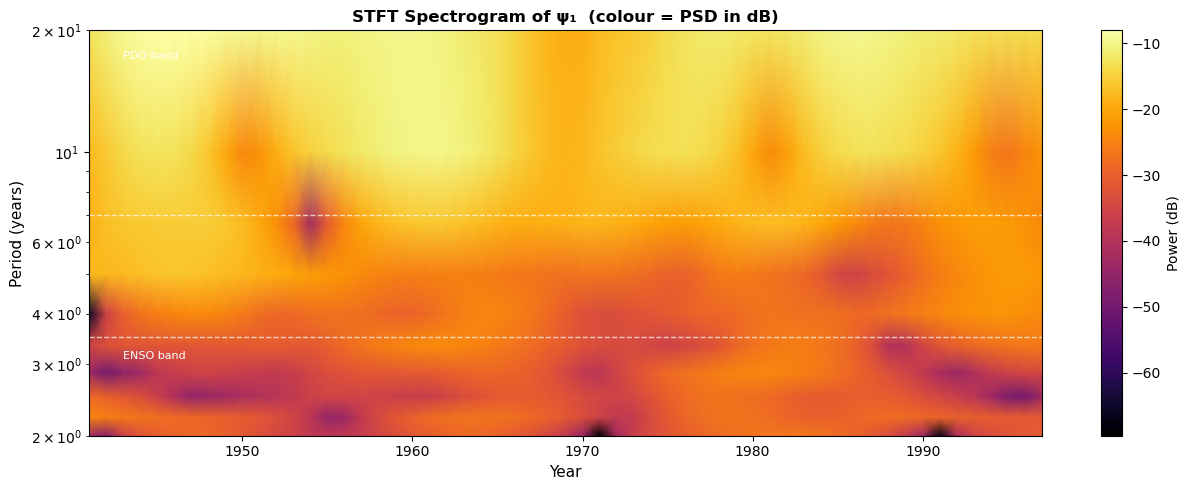

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# 5e — STFT SPECTROGRAM  (how periodicities shift over time)
# ══════════════════════════════════════════════════════════════════════════════
sig_zm_psi1 = sig_psi1 - sig_psi1.mean()
f_sg, t_sg, Sxx = spectrogram(sig_zm_psi1, fs=fs, window='hann',
                               nperseg=20, noverlap=19, scaling='density', mode='psd')
t_years = time_axis[0] + t_sg
with np.errstate(divide='ignore'):
    per_sg = np.where(f_sg > 0, 1.0 / f_sg, np.inf)

keep     = (f_sg > 0) & (per_sg <= n // 2)
per_plot = per_sg[keep]
Sxx_plot = Sxx[keep, :]

fig, ax = plt.subplots(figsize=(13, 5))
pcm = ax.pcolormesh(t_years, per_plot, 10 * np.log10(Sxx_plot + 1e-30),
                    cmap='inferno', shading='gouraud')
ax.set_yscale('log')
ax.set_ylabel('Period (years)', fontsize=11); ax.set_xlabel('Year', fontsize=11)
ax.set_title('STFT Spectrogram of ψ₁  (colour = PSD in dB)',
             fontsize=12, fontweight='bold')
plt.colorbar(pcm, ax=ax, label='Power (dB)')

for p in [3.5, 7, 20]:
    ax.axhline(p, color='white', lw=1.0, ls='--', alpha=0.7)
ax.text(t_years[2],  3.1, 'ENSO band', color='white', fontsize=8)
ax.text(t_years[2], 17.0, 'PDO band',  color='white', fontsize=8)

plt.tight_layout(); plt.show()
